<a href="https://colab.research.google.com/github/Vamsi630423/Amazon_ML_Challenge_2026/blob/main/Amazon_ML_Challenge_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn openpyxl

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC

from scipy.sparse import hstack

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Amazon_Reviews.csv.xlsx to Amazon_Reviews.csv.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("/content/Amazon_Reviews.csv.xlsx")

print(df.shape)
print(df.head())
print(df.columns.tolist())

(21214, 9)
      Reviewer Name                     Profile Link Country Review Count  \
0        Eugene ath  /users/66e8185ff1598352d6b3701a      US     1 review   
1  Daniel ohalloran  /users/5d75e460200c1f6a6373648c      GB    9 reviews   
2          p fisher  /users/546cfcf1000064000197b88f      GB   90 reviews   
3         Greg Dunn  /users/62c35cdbacc0ea0012ccaffa      AU    5 reviews   
4     Sheila Hannah  /users/5ddbe429478d88251550610e      GB    8 reviews   

                Review Date                  Rating  \
0  2024-09-16T13:44:26.000Z  Rated 1 out of 5 stars   
1  2024-09-16T18:26:46.000Z  Rated 1 out of 5 stars   
2  2024-09-16T21:47:39.000Z  Rated 1 out of 5 stars   
3  2024-09-17T07:15:49.000Z  Rated 1 out of 5 stars   
4  2024-09-16T18:37:17.000Z  Rated 1 out of 5 stars   

                                      Review Title  \
0       A Store That Doesn't Want to Sell Anything   
1         Had multiple orders one turned up andâ€¦   
2                      I informed

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21214 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Reviewer Name       21213 non-null  object
 1   Profile Link        21163 non-null  object
 2   Country             21054 non-null  object
 3   Review Count        21055 non-null  object
 4   Review Date         21055 non-null  object
 5   Rating              21055 non-null  object
 6   Review Title        21054 non-null  object
 7   Review Text         21055 non-null  object
 8   Date of Experience  20947 non-null  object
dtypes: object(9)
memory usage: 1.5+ MB


In [ ]:
df.isnull().sum()

,0
Reviewer Name,1
Profile Link,51
Country,160
Review Count,159
Review Date,159
Rating,159
Review Title,160
Review Text,159
Date of Experience,267


In [ ]:
print(df.columns.tolist())

['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']


In [ ]:
print(df.head(3).to_string())

      Reviewer Name                     Profile Link Country Review Count               Review Date                  Rating                                Review Title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                Review Text  Date of Experience
0        Eugene ath  /users/66e8185ff1598352d6b3701a      US     1 review  2024-09-16T13:44:26.000Z  Rated 1 out of 5 stars  A Store That Doesn't Want to Sell Anything                          

In [ ]:
print(df.shape)

(21214, 9)


In [ ]:
print([
    col for col in df.columns
    if any(word in col.lower() for word in ["rating", "star", "score", "label"])
])

['Rating']


In [ ]:
print(df.columns.tolist())
print(df.head(3).to_string())
print(df.shape)

['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']
      Reviewer Name                     Profile Link Country Review Count               Review Date                  Rating                                Review Title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                Review Text  Date of Experience
0        Eugene ath  /users/66e8185ff1598352d6b3701a  

In [ ]:
print(df["Rating"].isna().sum())
print(df["Rating"].dropna().unique())

159
['Rated 1 out of 5 stars' 'Rated 5 out of 5 stars'
 'Rated 2 out of 5 stars' 'Rated 4 out of 5 stars'
 'Rated 3 out of 5 stars']


In [ ]:
df["rating"] = (
    df["Rating"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
)

df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)

In [ ]:
print(df["rating"].isna().sum())
print(df["rating"].value_counts().sort_index())

159
rating
1.0    13123
2.0     1227
3.0      885
4.0     1292
5.0     4528
Name: count, dtype: int64


In [ ]:
print(df["rating"].unique())

[ 1.  5.  2.  4.  3. nan]


In [ ]:
print(df.shape)
print(df[["Rating", "rating"]].head(10))

(21214, 10)
                   Rating  rating
0  Rated 1 out of 5 stars     1.0
1  Rated 1 out of 5 stars     1.0
2  Rated 1 out of 5 stars     1.0
3  Rated 1 out of 5 stars     1.0
4  Rated 1 out of 5 stars     1.0
5  Rated 1 out of 5 stars     1.0
6  Rated 1 out of 5 stars     1.0
7  Rated 5 out of 5 stars     5.0
8  Rated 1 out of 5 stars     1.0
9  Rated 5 out of 5 stars     5.0


In [ ]:
print(df["rating"].value_counts().sort_index())

rating
1.0    13123
2.0     1227
3.0      885
4.0     1292
5.0     4528
Name: count, dtype: int64


In [ ]:
print(df["rating"].isna().sum())

159


In [ ]:
df["Review Text"] = df["Review Text"].fillna("").astype(str)
df["Review Title"] = df["Review Title"].fillna("").astype(str)

In [ ]:
df["combined_text"] = (
    df["Review Title"] + " " + df["Review Text"]
)

In [ ]:
print(df["combined_text"].head())

0    A Store That Doesn't Want to Sell Anything I r...
1    Had multiple orders one turned up andâ€¦ Had m...
2    I informed these reprobates I informed these r...
3    Advertise one price then increase it on websit...
4    If I could give a lower rate I would If I coul...
Name: combined_text, dtype: object


In [ ]:
df["review_length"] = df["Review Text"].str.len()

df["word_count"] = df["Review Text"].str.split().str.len()

df["title_length"] = df["Review Title"].str.len()

In [ ]:
print(
    df[
        ["rating", "review_length", "word_count", "title_length"]
    ].head()
)

   rating  review_length  word_count  title_length
0     1.0            590         106            42
1     1.0            293          53            40
2     1.0            617         122            27
3     1.0            450          82            47
4     1.0            538         100            36


In [ ]:
print("Missing ratings:", df["rating"].isna().sum())

Missing ratings: 159


In [ ]:
df = df.dropna(subset=["rating"]).copy()

In [ ]:
df["rating"] = df["rating"].astype(int)

In [ ]:
print("Missing ratings:", df["rating"].isna().sum())
print("Ratings:", sorted(df["rating"].unique()))
print("Dataset shape:", df.shape)

Missing ratings: 0
Ratings: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Dataset shape: (21055, 14)


In [ ]:
X = df["combined_text"]
y = df["rating"]

In [ ]:
print("X:", len(X))
print("y:", len(y))
print("Missing X:", X.isna().sum())
print("Missing y:", y.isna().sum())

X: 21055
y: 21055
Missing X: 0
Missing y: 0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Validation:", len(X_val))

Training: 16844
Validation: 4211


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=100000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print("Training TF-IDF:", X_train_tfidf.shape)
print("Validation TF-IDF:", X_val_tfidf.shape)

Training TF-IDF: (16844, 100000)
Validation TF-IDF: (4211, 100000)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train_tfidf, y_train)

pred_lr = lr.predict(X_val_tfidf)

score_lr = f1_score(
    y_val,
    pred_lr,
    average="macro"
)

print("Logistic Regression Macro-F1:", score_lr)

Logistic Regression Macro-F1: 0.506416039678622


In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    class_weight="balanced"
)

svm.fit(X_train_tfidf, y_train)

pred_svm = svm.predict(X_val_tfidf)

score_svm = f1_score(
    y_val,
    pred_svm,
    average="macro"
)

print("Linear SVM Macro-F1:", score_svm)

Linear SVM Macro-F1: 0.46831721732325005


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

pred_nb = nb.predict(X_val_tfidf)

score_nb = f1_score(
    y_val,
    pred_nb,
    average="macro"
)

print("Naive Bayes Macro-F1:", score_nb)

Naive Bayes Macro-F1: 0.2879661416530678


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes"
    ],
    "Macro-F1": [
        score_lr,
        score_svm,
        score_nb
    ]
})

print(results)

                 Model  Macro-F1
0  Logistic Regression  0.506416
1           Linear SVM  0.468317
2          Naive Bayes  0.287966


In [ ]:
print(results)

                 Model  Macro-F1
0  Logistic Regression  0.506416
1           Linear SVM  0.468317
2          Naive Bayes  0.287966


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

C_values = [0.1, 0.5, 1, 2, 5, 10]

best_score = 0
best_C = None
best_model = None

for C in C_values:

    model = LogisticRegression(
        C=C,
        max_iter=1500,
        class_weight="balanced"
    )

    model.fit(X_train_tfidf, y_train)

    predictions = model.predict(X_val_tfidf)

    score = f1_score(
        y_val,
        predictions,
        average="macro"
    )

    print(f"C = {C}, Macro-F1 = {score:.4f}")

    if score > best_score:
        best_score = score
        best_C = C
        best_model = model

print("\nBest C:", best_C)
print("Best Macro-F1:", best_score)

C = 0.1, Macro-F1 = 0.4842
C = 0.5, Macro-F1 = 0.5053
C = 1, Macro-F1 = 0.5064
C = 2, Macro-F1 = 0.4934
C = 5, Macro-F1 = 0.4898
C = 10, Macro-F1 = 0.4818

Best C: 1
Best Macro-F1: 0.506416039678622


In [ ]:
ngram_range=(1, 2)

In [ ]:
tfidf2 = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    max_features=150000,
    sublinear_tf=True
)

X_train_tfidf2 = tfidf2.fit_transform(X_train)
X_val_tfidf2 = tfidf2.transform(X_val)

print(X_train_tfidf2.shape)

(16844, 150000)


In [ ]:
lr2 = LogisticRegression(
    C=best_C,
    max_iter=1500,
    class_weight="balanced"
)

lr2.fit(X_train_tfidf2, y_train)

pred2 = lr2.predict(X_val_tfidf2)

score2 = f1_score(
    y_val,
    pred2,
    average="macro"
)

print("TF-IDF Configuration A:", score2)

TF-IDF Configuration A: 0.5016225245196698


In [ ]:
char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=100000,
    sublinear_tf=True
)

X_train_char = char_tfidf.fit_transform(X_train)
X_val_char = char_tfidf.transform(X_val)

print(X_train_char.shape)

(16844, 100000)


In [ ]:
char_lr = LogisticRegression(
    C=best_C,
    max_iter=1500,
    class_weight="balanced"
)

char_lr.fit(X_train_char, y_train)

pred_char = char_lr.predict(X_val_char)

score_char = f1_score(
    y_val,
    pred_char,
    average="macro"
)

print("Character TF-IDF Macro-F1:", score_char)

Character TF-IDF Macro-F1: 0.49418128730406574


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_val,
    best_model.predict(X_val_tfidf)
))

              precision    recall  f1-score   support

           1       0.90      0.89      0.89      2625
           2       0.21      0.27      0.24       245
           3       0.24      0.21      0.22       177
           4       0.36      0.38      0.37       258
           5       0.81      0.80      0.81       906

    accuracy                           0.77      4211
   macro avg       0.51      0.51      0.51      4211
weighted avg       0.78      0.77      0.78      4211



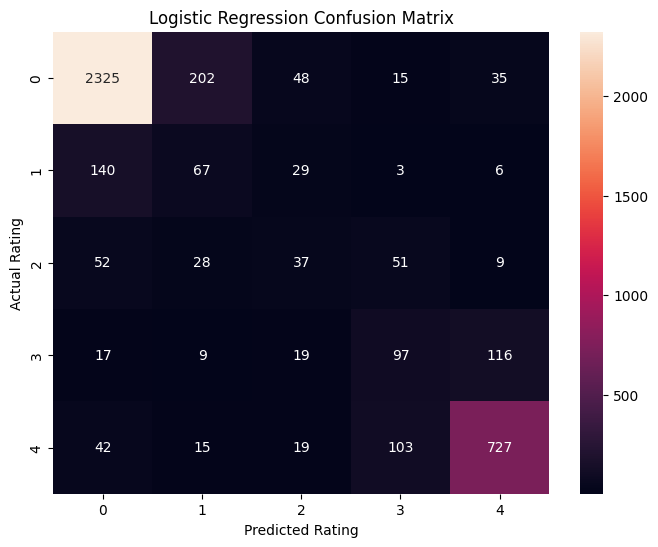

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_predictions = best_model.predict(X_val_tfidf)

cm = confusion_matrix(y_val, best_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

best_predictions = best_model.predict(X_val_tfidf)

print(classification_report(
    y_val,
    best_predictions,
    digits=4
))

              precision    recall  f1-score   support

           1     0.9026    0.8857    0.8941      2625
           2     0.2087    0.2735    0.2367       245
           3     0.2434    0.2090    0.2249       177
           4     0.3606    0.3760    0.3681       258
           5     0.8141    0.8024    0.8082       906

    accuracy                         0.7725      4211
   macro avg     0.5059    0.5093    0.5064      4211
weighted avg     0.7823    0.7725    0.7770      4211



In [ ]:
class_weight="balanced"

In [ ]:
custom_weights = {
    1: 1.0,
    2: 2.0,
    3: 2.0,
    4: 1.2,
    5: 1.0
}

In [ ]:
weighted_lr = LogisticRegression(
    C=best_C,
    max_iter=1500,
    class_weight=custom_weights
)

weighted_lr.fit(X_train_tfidf, y_train)

weighted_pred = weighted_lr.predict(X_val_tfidf)

weighted_score = f1_score(
    y_val,
    weighted_pred,
    average="macro"
)

print("Custom class weights Macro-F1:", weighted_score)

Custom class weights Macro-F1: 0.42099164916060416


In [ ]:
print("Previous Macro-F1:", best_score)
print("New Macro-F1:", weighted_score)

Previous Macro-F1: 0.506416039678622
New Macro-F1: 0.42099164916060416


In [ ]:
ngram_range=(1, 2)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=100000,
    sublinear_tf=True
)

X_train_char = char_tfidf.fit_transform(X_train)
X_val_char = char_tfidf.transform(X_val)

print("Character TF-IDF:", X_train_char.shape)

Character TF-IDF: (16844, 100000)


In [ ]:
char_lr = LogisticRegression(
    C=best_C,
    max_iter=1500,
    class_weight="balanced"
)

char_lr.fit(X_train_char, y_train)

char_pred = char_lr.predict(X_val_char)

char_score = f1_score(
    y_val,
    char_pred,
    average="macro"
)

print("Character TF-IDF Macro-F1:", char_score)

Character TF-IDF Macro-F1: 0.49418128730406574


In [ ]:
print(classification_report(
    y_val,
    best_predictions,
    digits=4
))

              precision    recall  f1-score   support

           1     0.9026    0.8857    0.8941      2625
           2     0.2087    0.2735    0.2367       245
           3     0.2434    0.2090    0.2249       177
           4     0.3606    0.3760    0.3681       258
           5     0.8141    0.8024    0.8082       906

    accuracy                         0.7725      4211
   macro avg     0.5059    0.5093    0.5064      4211
weighted avg     0.7823    0.7725    0.7770      4211



In [ ]:
custom_weights = {
    1: 1.0,
    2: 2.0,
    3: 2.0,
    4: 1.5,
    5: 1.0
}

weighted_lr = LogisticRegression(
    C=best_C,
    max_iter=1500,
    class_weight=custom_weights
)

weighted_lr.fit(X_train_tfidf, y_train)

weighted_pred = weighted_lr.predict(X_val_tfidf)

weighted_score = f1_score(
    y_val,
    weighted_pred,
    average="macro"
)

print("Previous Macro-F1:", best_score)
print("New Macro-F1:", weighted_score)

Previous Macro-F1: 0.506416039678622
New Macro-F1: 0.4363409750302468


In [ ]:
print(classification_report(
    y_val,
    weighted_pred,
    digits=4
))

              precision    recall  f1-score   support

           1     0.8380    0.9912    0.9082      2625
           2     0.3043    0.0286    0.0522       245
           3     0.5517    0.0904    0.1553       177
           4     0.4731    0.1705    0.2507       258
           5     0.7919    0.8400    0.8152       906

    accuracy                         0.8145      4211
   macro avg     0.5918    0.4241    0.4363      4211
weighted avg     0.7626    0.8145    0.7665      4211



In [ ]:
import pandas as pd
import numpy as np

# Remove rows without a valid target
df = df.dropna(subset=["rating"]).copy()

# Make rating integer
df["rating"] = df["rating"].astype(int)

# Clean text columns
df["Review Text"] = df["Review Text"].fillna("").astype(str)
df["Review Title"] = df["Review Title"].fillna("").astype(str)

# Combine title + review
df["combined_text"] = (
    df["Review Title"] + " " + df["Review Text"]
)

# Remove empty reviews
df = df[df["combined_text"].str.strip() != ""]

print("Dataset shape:", df.shape)
print("\nRating distribution:")
print(df["rating"].value_counts().sort_index())

Dataset shape: (21055, 14)

Rating distribution:
rating
1    13123
2     1227
3      885
4     1292
5     4528
Name: count, dtype: int64


In [ ]:
before = len(df)

df = df.drop_duplicates(
    subset=["combined_text"]
).copy()

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 21055
Rows after: 21021
Duplicates removed: 34


In [ ]:
df["review_length"] = df["Review Text"].str.len()

df["word_count"] = (
    df["Review Text"]
    .str.split()
    .str.len()
)

df["title_length"] = (
    df["Review Title"].str.len()
)

df["exclamation_count"] = (
    df["Review Text"].str.count("!")
)

df["question_count"] = (
    df["Review Text"].str.count(r"\?")
)

print(
    df[
        [
            "rating",
            "review_length",
            "word_count",
            "title_length",
            "exclamation_count",
            "question_count"
        ]
    ].head()
)

   rating  review_length  word_count  title_length  exclamation_count  \
0       1            590         106            42                  0   
1       1            293          53            40                  0   
2       1            617         122            27                  3   
3       1            450          82            47                  0   
4       1            538         100            36                  5   

   question_count  
0               0  
1               0  
2               0  
3               0  
4               0  


rating
1    13115
2     1226
3      882
4     1280
5     4518
Name: count, dtype: int64


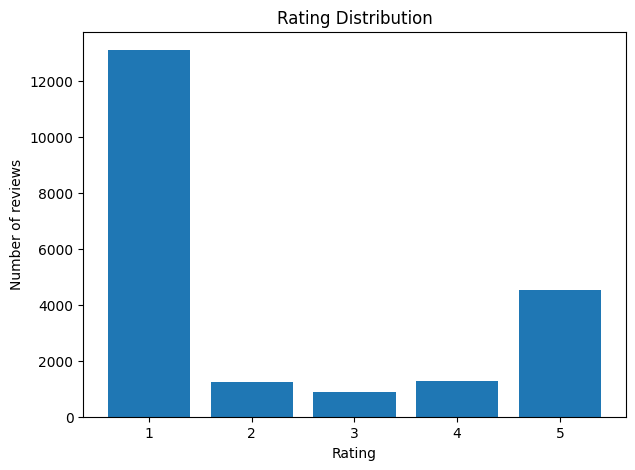

In [ ]:
import matplotlib.pyplot as plt

rating_counts = (
    df["rating"]
    .value_counts()
    .sort_index()
)

print(rating_counts)

plt.figure(figsize=(7, 5))

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.xlabel("Rating")
plt.ylabel("Number of reviews")
plt.title("Rating Distribution")

plt.show()

In [ ]:
class_weight="balanced"

In [ ]:
from sklearn.model_selection import train_test_split

X = df["combined_text"]
y = df["rating"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Validation:", len(X_val))

Training: 16816
Validation: 4205


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

word_tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=200000,
    sublinear_tf=True
)

X_train_word = word_tfidf.fit_transform(X_train)

X_val_word = word_tfidf.transform(X_val)

print("Word TF-IDF:")
print("Train:", X_train_word.shape)
print("Validation:", X_val_word.shape)

Word TF-IDF:
Train: (16816, 118829)
Validation: (4205, 118829)


In [ ]:
char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=100000,
    sublinear_tf=True
)

X_train_char = char_tfidf.fit_transform(X_train)

X_val_char = char_tfidf.transform(X_val)

print("Character TF-IDF:")
print("Train:", X_train_char.shape)
print("Validation:", X_val_char.shape)

Character TF-IDF:
Train: (16816, 100000)
Validation: (4205, 100000)


In [ ]:
from scipy.sparse import hstack

X_train_combined = hstack([
    X_train_word,
    X_train_char
]).tocsr()

X_val_combined = hstack([
    X_val_word,
    X_val_char
]).tocsr()

print("Combined training shape:", X_train_combined.shape)
print("Combined validation shape:", X_val_combined.shape)

Combined training shape: (16816, 218829)
Combined validation shape: (4205, 218829)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

combined_lr = LogisticRegression(
    C=1,
    max_iter=1500,
    class_weight="balanced",
    solver="liblinear"
)

combined_lr.fit(
    X_train_combined,
    y_train
)

pred_combined_lr = combined_lr.predict(
    X_val_combined
)

score_combined_lr = f1_score(
    y_val,
    pred_combined_lr,
    average="macro"
)

print(
    "Word + Character Logistic Regression:",
    score_combined_lr
)

Word + Character Logistic Regression: 0.5042708424723406


In [ ]:
C_values = [
    0.1,
    0.25,
    0.5,
    1,
    2,
    3,
    5
]

tuning_results = []

best_score = -1
best_C = None
best_lr = None
best_predictions = None

for C in C_values:

    model = LogisticRegression(
        C=C,
        max_iter=1500,
        class_weight="balanced",
        solver="liblinear"
    )

    model.fit(
        X_train_combined,
        y_train
    )

    predictions = model.predict(
        X_val_combined
    )

    score = f1_score(
        y_val,
        predictions,
        average="macro"
    )

    tuning_results.append({
        "C": C,
        "Macro-F1": score
    })

    print(
        f"C = {C:<5} | Macro-F1 = {score:.4f}"
    )

    if score > best_score:
        best_score = score
        best_C = C
        best_lr = model
        best_predictions = predictions

print("\n==========================")
print("Best C:", best_C)
print("Best Macro-F1:", best_score)
print("==========================")

C = 0.1   | Macro-F1 = 0.4668
C = 0.25  | Macro-F1 = 0.4944
C = 0.5   | Macro-F1 = 0.5030
C = 1     | Macro-F1 = 0.5043
C = 2     | Macro-F1 = 0.5009
C = 3     | Macro-F1 = 0.4977
C = 5     | Macro-F1 = 0.4924

Best C: 1
Best Macro-F1: 0.5042708424723406


In [ ]:
tuning_df = pd.DataFrame(tuning_results)

print(tuning_df)

      C  Macro-F1
0  0.10  0.466822
1  0.25  0.494442
2  0.50  0.503007
3  1.00  0.504271
4  2.00  0.500853
5  3.00  0.497747
6  5.00  0.492430


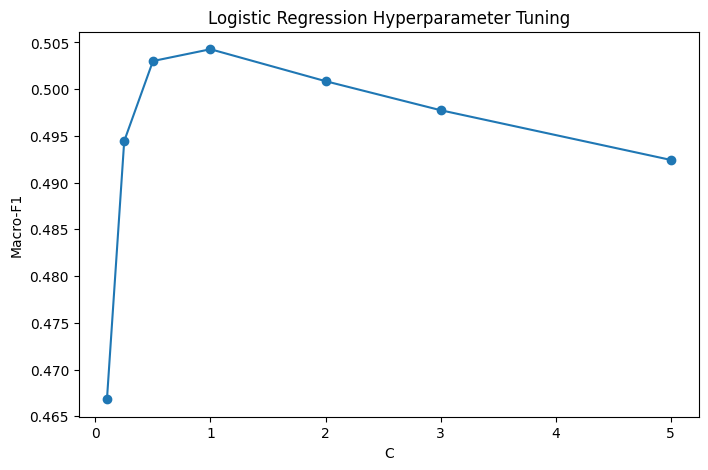

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    tuning_df["C"],
    tuning_df["Macro-F1"],
    marker="o"
)

plt.xlabel("C")
plt.ylabel("Macro-F1")
plt.title("Logistic Regression Hyperparameter Tuning")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        best_predictions,
        digits=4
    )
)

              precision    recall  f1-score   support

           1     0.8763    0.9695    0.9206      2624
           2     0.2262    0.0776    0.1155       245
           3     0.4337    0.2045    0.2780       176
           4     0.4588    0.3047    0.3662       256
           5     0.8145    0.8695    0.8411       904

    accuracy                         0.8235      4205
   macro avg     0.5619    0.4852    0.5043      4205
weighted avg     0.7812    0.8235    0.7959      4205



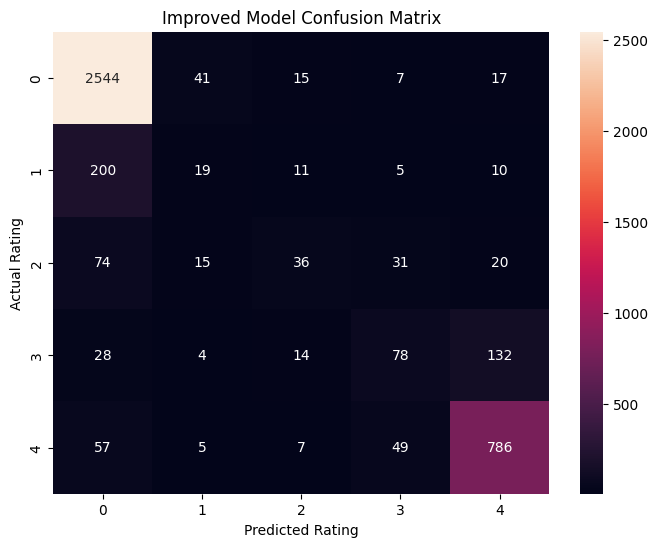

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_val,
    best_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Improved Model Confusion Matrix")

plt.show()

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1,
    class_weight="balanced"
)

svm_model.fit(
    X_train_combined,
    y_train
)

svm_pred = svm_model.predict(
    X_val_combined
)

svm_score = f1_score(
    y_val,
    svm_pred,
    average="macro"
)

print(
    "Combined TF-IDF + Linear SVM Macro-F1:",
    svm_score
)

Combined TF-IDF + Linear SVM Macro-F1: 0.4881605274394759


In [ ]:
svm_results = []

best_svm_score = -1
best_svm_C = None
best_svm_model = None
best_svm_predictions = None

for C in [0.1, 0.25, 0.5, 1, 2, 3]:

    model = LinearSVC(
        C=C,
        class_weight="balanced"
    )

    model.fit(
        X_train_combined,
        y_train
    )

    predictions = model.predict(
        X_val_combined
    )

    score = f1_score(
        y_val,
        predictions,
        average="macro"
    )

    svm_results.append({
        "C": C,
        "Macro-F1": score
    })

    print(
        f"SVM C = {C:<5} | Macro-F1 = {score:.4f}"
    )

    if score > best_svm_score:
        best_svm_score = score
        best_svm_C = C
        best_svm_model = model
        best_svm_predictions = predictions

print("\nBest SVM C:", best_svm_C)
print("Best SVM Macro-F1:", best_svm_score)

SVM C = 0.1   | Macro-F1 = 0.5052
SVM C = 0.25  | Macro-F1 = 0.4982
SVM C = 0.5   | Macro-F1 = 0.4964
SVM C = 1     | Macro-F1 = 0.4882
SVM C = 2     | Macro-F1 = 0.4778
SVM C = 3     | Macro-F1 = 0.4714

Best SVM C: 0.1
Best SVM Macro-F1: 0.5052358929403509


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Original Linear SVM",
        "Original Naive Bayes",
        "Word + Character Logistic Regression",
        "Word + Character Linear SVM"
    ],
    "Macro-F1": [
        0.506416,
        0.468317,
        0.287966,
        best_score,
        best_svm_score
    ]
})

print(comparison)

                                  Model  Macro-F1
0          Original Logistic Regression  0.506416
1                   Original Linear SVM  0.468317
2                  Original Naive Bayes  0.287966
3  Word + Character Logistic Regression  0.504271
4           Word + Character Linear SVM  0.505236


In [ ]:
baseline = 0.506416

target = baseline * 1.10

print("Baseline:", baseline)
print("10% improvement target:", target)

print("Best Logistic Regression:", best_score)
print("Best SVM:", best_svm_score)

if max(best_score, best_svm_score) >= target:
    print("TARGET ACHIEVED")
else:
    print("TARGET NOT YET ACHIEVED")

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.3 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df["sentiment"] = df["combined_text"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

print(
    df.groupby("rating")["sentiment"].mean()
)

rating
1   -0.258292
2   -0.053310
3    0.204014
4    0.592205
5    0.724188
Name: sentiment, dtype: float64


In [ ]:
final_tfidf_word = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=200000,
    sublinear_tf=True
)

final_tfidf_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=100000,
    sublinear_tf=True
)

In [ ]:
X_full_word = final_tfidf_word.fit_transform(
    df["combined_text"]
)

X_full_char = final_tfidf_char.fit_transform(
    df["combined_text"]
)

In [ ]:
X_full = hstack([
    X_full_word,
    X_full_char
]).tocsr()

y_full = df["rating"]

print(X_full.shape)

(21021, 240288)


In [ ]:
final_model = LogisticRegression(
    C=best_C,
    max_iter=1500,
    class_weight="balanced",
    solver="liblinear"
)

final_model.fit(
    X_full,
    y_full
)

LogisticRegression(C=1, class_weight='balanced', max_iter=1500,
                   solver='liblinear')

In [ ]:
import os

print(os.listdir("/content"))

['.config', '.ipynb_checkpoints', 'Amazon_Reviews.csv.xlsx', 'sample_data']


In [ ]:
df = pd.read_excel("/content/Amazon_Reviews.csv.xlsx")

print(df.shape)
print(df.head())
print(df.columns.tolist())

(21214, 9)
      Reviewer Name                     Profile Link Country Review Count  \
0        Eugene ath  /users/66e8185ff1598352d6b3701a      US     1 review   
1  Daniel ohalloran  /users/5d75e460200c1f6a6373648c      GB    9 reviews   
2          p fisher  /users/546cfcf1000064000197b88f      GB   90 reviews   
3         Greg Dunn  /users/62c35cdbacc0ea0012ccaffa      AU    5 reviews   
4     Sheila Hannah  /users/5ddbe429478d88251550610e      GB    8 reviews   

                Review Date                  Rating  \
0  2024-09-16T13:44:26.000Z  Rated 1 out of 5 stars   
1  2024-09-16T18:26:46.000Z  Rated 1 out of 5 stars   
2  2024-09-16T21:47:39.000Z  Rated 1 out of 5 stars   
3  2024-09-17T07:15:49.000Z  Rated 1 out of 5 stars   
4  2024-09-16T18:37:17.000Z  Rated 1 out of 5 stars   

                                      Review Title  \
0       A Store That Doesn't Want to Sell Anything   
1         Had multiple orders one turned up andâ€¦   
2                      I informed

In [ ]:
df["Review Text"] = (
    df["Review Text"]
    .fillna("")
    .astype(str)
)

df["Review Title"] = (
    df["Review Title"]
    .fillna("")
    .astype(str)
)

df["combined_text"] = (
    df["Review Title"] + " " +
    df["Review Text"]
)

In [ ]:
df["Review Text"] = (
    df["Review Text"]
    .fillna("")
    .astype(str)
)

df["Review Title"] = (
    df["Review Title"]
    .fillna("")
    .astype(str)
)

df["combined_text"] = (
    df["Review Title"] + " " +
    df["Review Text"]
)

In [ ]:
X_df_word = final_tfidf_word.transform(
    df["combined_text"]
)

X_df_char = final_tfidf_char.transform(
    df["combined_text"]
)

X_df = hstack([
    X_df_word,
    X_df_char
]).tocsr()

print(X_df.shape)

(21214, 240288)


In [ ]:
df_predictions = final_model.predict(X_df)

print(df_predictions[:20])

[1 1 1 1 1 1 1 5 1 4 5 1 2 1 1 1 1 1 1 1]


In [ ]:
submission = pd.DataFrame({
    "rating": df_predictions
})

submission.to_csv(
    "/content/submission.csv",
    index=False
)

print(submission.head())
print("Submission shape:", submission.shape)

   rating
0       1
1       1
2       1
3       1
4       1
Submission shape: (21214, 1)


In [ ]:
submission = pd.DataFrame({
    "rating": df_predictions
})

submission.to_csv(
    "/content/submission.csv",
    index=False
)

print(submission.head())

   rating
0       1
1       1
2       1
3       1
4       1


In [ ]:
print(df.columns.tolist())

['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience', 'combined_text']


In [ ]:
print(comparison)
print("Best score:", max(best_score, best_svm_score))

                                  Model  Macro-F1
0          Original Logistic Regression  0.506416
1                   Original Linear SVM  0.468317
2                  Original Naive Bayes  0.287966
3  Word + Character Logistic Regression  0.504271
4           Word + Character Linear SVM  0.505236
Best score: 0.5052358929403509
